# **Convolución 1D**

Este cuaderno explora las capas convolucionales 1D.

Ejecuta las celdas en orden. En varios lugares verás la palabra "TAREA": sigue esas instrucciones, anticipa qué ocurrirá o escribe el código necesario para completar las funciones.


**Nota**

En estas funciones usaremos la convención habitual de dilatación: una dilatación de 1 aplica el filtro sobre elementos contiguos; una dilatación de 2 deja un espacio entre elementos consecutivos del filtro.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Define una señal a la que aplicaremos convolución
x = [5.2, 5.3, 5.4, 5.1, 10.1, 10.3, 9.9, 10.3, 3.2, 3.4, 3.3, 3.1]

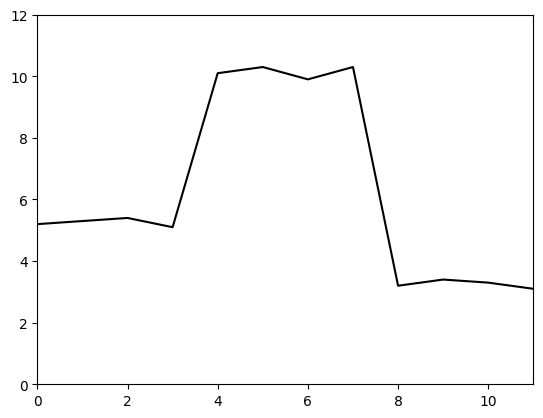

In [3]:
# Dibuja la señal
fig,ax = plt.subplots()
ax.plot(x, 'k-')
ax.set_xlim(0,11)
ax.set_ylim(0, 12)
plt.show()

In [4]:
# Definamos una operación de convolución con relleno de ceros
# con tamaño de kernel 3, paso 1 y dilatación 1.
# Escríbela tú mismo; no llames a una rutina de biblioteca.
# Recuerda que los arreglos de Python se indexan desde cero.
def conv_3_1_1_zp(x_in, omega):
    x_out = np.zeros_like(x_in)
    
    # TAREA -- escribe esta función
    # Función: y[i]=ω0​x[i−1]+ω1​x[i]+ω2​x[i+1]
    for i in range(len(x_in)):
        for k in range(3):
            idx = i + k - 1
            if 0 <= idx < len(x_in):
                x_out[i] += omega[k] * x_in[idx]



    return x_out

Ahora veamos qué tipo de operaciones puede hacer una convolución.
Primero puede promediar valores cercanos y suavizar la función:

La suma de la salida es 71.1, debe ser 71.1


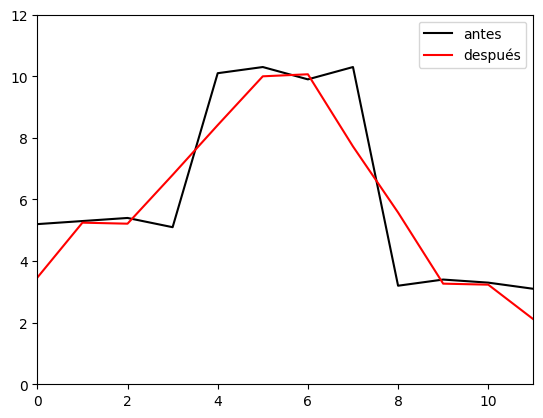

In [5]:

omega = [0.33,0.33,0.33]
h = conv_3_1_1_zp(x, omega)

# Comprueba que lo calculaste correctamente
print(f"La suma de la salida es {np.sum(h):3.3}, debe ser 71.1")

# Dibuja la señal
fig,ax = plt.subplots()
ax.plot(x, 'k-',label='antes')
ax.plot(h, 'r-',label='después')
ax.set_xlim(0,11)
ax.set_ylim(0, 12)
ax.legend()
plt.show()

Observa que la función roja es una versión suavizada de la negra, porque promedia valores adyacentes. Sin embargo, las primeras y últimas salidas son bastante menores que la curva original. Asegúrate de entender por qué.<br><br>

Con pesos diferentes, la convolución puede detectar cambios bruscos en la función:

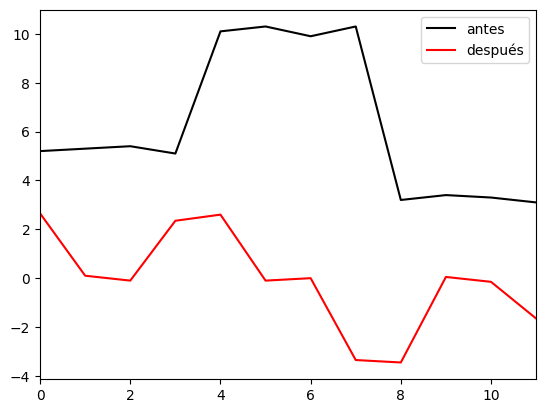

In [6]:

omega = [-0.5,0,0.5]
h2 = conv_3_1_1_zp(x, omega)

# Dibuja la señal
fig,ax = plt.subplots()
ax.plot(x, 'k-',label='antes')
ax.plot(h2, 'r-',label='después')
ax.set_xlim(0,11)
# ax.set_ylim(0, 12)
ax.legend()
plt.show()

Observa que la convolución produce un pico donde la función original sube y un valle donde baja. Es aproximadamente cero donde la función es localmente plana; por eso esta convolución aproxima una derivada. <br><br>

Ahora definamos algunas convoluciones con distintos parámetros.

In [7]:
# Definamos una operación de convolución con relleno de ceros
# con tamaño de kernel 3, paso 2 y dilatación 1.
# Escríbela tú mismo; no llames a una rutina de biblioteca.
def conv_3_2_1_zp(x_in, omega):
    x_out = np.zeros(int(np.ceil(len(x_in)/2)))
    # TAREA -- escribe esta función
    for i in range(len(x_out)):
        pos = i * 2
        for k in range(3):
            idx = pos + k - 1
            if 0 <= idx < len(x_in):
                x_out[i] += omega[k] * x_in[idx]
    x_out = x_out


    return x_out

In [8]:
omega = [0.33,0.33,0.33]
h3 = conv_3_2_1_zp(x, omega)

# Si lo hiciste bien, la longitud de salida debe ser seis y debe
# contener uno de cada dos valores de la convolución original con paso 1
print(h)
print(h3)

[ 3.465  5.247  5.214  6.798  8.415  9.999 10.065  7.722  5.577  3.267
  3.234  2.112]
[ 3.465  5.214  8.415 10.065  5.577  3.234]


In [9]:
# Definamos una operación de convolución con relleno de ceros
# con tamaño de kernel 5, paso 1 y dilatación 1.
# Escríbela tú mismo; no llames a una rutina de biblioteca.
def conv_5_1_1_zp(x_in, omega):
    x_out = np.zeros_like(x_in)
    
    # TAREA -- escribe esta función
    for i in range(len(x_in)):
        for k in range(5):
            idx = i + k - 2
            if 0 <= idx < len(x_in):
                x_out[i] += omega[k] * x_in[idx]



    return x_out

La suma de la salida es 69.6, debe ser 69.6


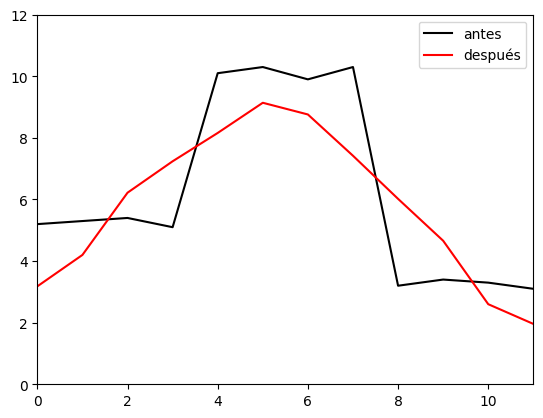

In [10]:

omega2 = [0.2, 0.2, 0.2, 0.2, 0.2]
h4 = conv_5_1_1_zp(x, omega2)

# Comprueba que lo calculaste correctamente
print(f"La suma de la salida es {np.sum(h4):3.3}, debe ser 69.6")

# Dibuja la señal
fig,ax = plt.subplots()
ax.plot(x, 'k-',label='antes')
ax.plot(h4, 'r-',label='después')
ax.set_xlim(0,11)
ax.set_ylim(0, 12)
ax.legend()
plt.show()

In [11]:
# Finalmente, definamos una operación de convolución con relleno de ceros
# con tamaño de kernel 3, paso 1 y dilatación 2.
# Escríbela tú mismo; no llames a una rutina de biblioteca.
# Recuerda que los arreglos de Python se indexan desde cero.
def conv_3_1_2_zp(x_in, omega):
    x_out = np.zeros_like(x_in)
    
    # TAREA -- escribe esta función
    for i in range(len(x_in)):
        for k in range(3):
            idx = i + (k - 1) * 2
            if 0 <= idx < len(x_in):
                x_out[i] += omega[k] * x_in[idx]


    return x_out

La suma de la salida es 68.3, debe ser 68.3


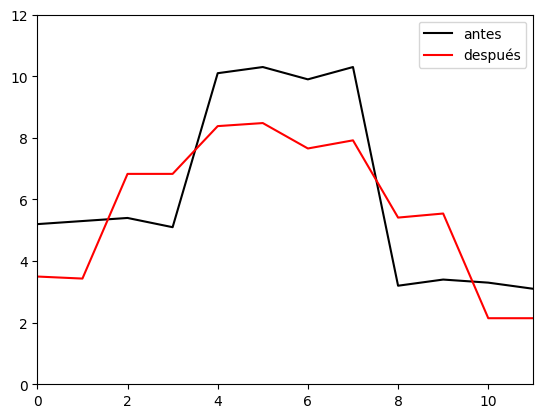

In [12]:
omega = [0.33,0.33,0.33]
h5 = conv_3_1_2_zp(x, omega)

# Comprueba que lo calculaste correctamente
print(f"La suma de la salida es {np.sum(h5):3.3}, debe ser 68.3")

# Dibuja la señal
fig,ax = plt.subplots()
ax.plot(x, 'k-',label='antes')
ax.plot(h5, 'r-',label='después')
ax.set_xlim(0,11)
ax.set_ylim(0, 12)
ax.legend()
plt.show()

Finalmente, representemos las convoluciones como matrices completas y comprobemos que obtenemos el mismo resultado.

In [14]:
# Calcula la matriz de convolución
def get_conv_mat_3_1_1_zp(n_out, omega):
  omega_mat = np.zeros((n_out,n_out))
  
  # TAREA: completa esta matriz
  for i in range(n_out):
        for k in range(3):
            idx = i + k - 1
            if 0 <= idx < n_out:
                omega_mat[i, idx] = omega[k]



  return omega_mat

In [15]:
# Ejecuta la convolución original
omega = np.array([-1.0,0.5,-0.2])
h6 = conv_3_1_1_zp(x, omega)
print(h6)

# Si lo hiciste bien, deberías obtener la misma respuesta
omega_mat = get_conv_mat_3_1_1_zp(len(x), omega)
h7 = np.matmul(omega_mat, x)
print(h7)


[ 1.54 -3.63 -3.62 -4.87 -2.11 -6.93 -7.41 -5.39 -9.38 -2.16 -2.37 -1.75]
[ 1.54 -3.63 -3.62 -4.87 -2.11 -6.93 -7.41 -5.39 -9.38 -2.16 -2.37 -1.75]


# T A R E A

## ¿Qué esperas que ocurra si aplicamos dos veces la última convolución?
Al aplicar dos veces la misma convolución, el efecto del filtro se acumula sobre la señal.

## ¿Se puede representar como una sola convolución?
En lugar de realizar dos convoluciones por separado, es posible representarlas como una sola convolución utilizando un nuevo kernel equivalente.

## ¿Cuál sería?
Este nuevo kernel se obtiene al convolucionar el filtro consigo mismo. Para el filtro [-1.0, 0.5, -0.2], el kernel equivalente es:

[1.0, -1.0, 0.65, -0.2, 0.04]

Por lo tanto, aplicar dos veces la convolución de tamaño 3 es equivalente a aplicar una sola convolución con un kernel de tamaño 5 formado por esos nuevos coeficientes.
